In [ ]:
import pandas as pd
df = pd.read_csv("./ND Analytics Challenge Dataset.csv")
df

,datetime,sum_amount,avg_amount_per_user,anomaly
0,2017-05-16 00:10:00,26.323942,16.474923,False
1,2017-05-16 00:40:00,25.363050,15.325484,False
2,2017-05-16 01:10:00,25.443192,11.128038,False
3,2017-05-16 01:40:00,26.149407,10.833380,False
4,2017-05-16 02:10:00,25.801580,10.858455,False
...,...,...,...,...
12269,2018-01-26 14:40:00,26.103956,13.934151,False
12270,2018-01-26 15:10:00,26.499405,14.409160,False
12271,2018-01-26 15:40:00,26.380532,14.416234,False
12272,2018-01-26 16:10:00,26.207231,14.174578,False


In [ ]:
df["datetime"] = pd.to_datetime(df["datetime"])
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour
df = df.drop(columns=['datetime'])
df["sum_distance_from_avg"] = df["sum_amount"] - df["avg_amount_per_user"]
df["hour_0_thru_13"] = df["hour"] <= 13
df

,sum_amount,avg_amount_per_user,anomaly,year,month,hour,sum_distance_from_avg,hour_0_thru_13
0,26.323942,16.474923,False,2017,5,0,9.849019,True
1,25.363050,15.325484,False,2017,5,0,10.037566,True
2,25.443192,11.128038,False,2017,5,1,14.315154,True
3,26.149407,10.833380,False,2017,5,1,15.316027,True
4,25.801580,10.858455,False,2017,5,2,14.943125,True
...,...,...,...,...,...,...,...,...
12269,26.103956,13.934151,False,2018,1,14,12.169805,False
12270,26.499405,14.409160,False,2018,1,15,12.090245,False
12271,26.380532,14.416234,False,2018,1,15,11.964298,False
12272,26.207231,14.174578,False,2018,1,16,12.032653,False


In [ ]:
import scipy.stats as stats
df["sum_amount_zscore"] = stats.zscore(df["sum_amount"])
df["avg_amount_zscore"] = stats.zscore(df["avg_amount_per_user"])
df["distance_zscore"] = stats.zscore(df["sum_distance_from_avg"])
df

,sum_amount,avg_amount_per_user,anomaly,year,month,hour,sum_distance_from_avg,hour_0_thru_13,sum_amount_zscore,avg_amount_zscore,distance_zscore
0,26.323942,16.474923,False,2017,5,0,9.849019,True,-0.470588,1.407180,-2.286500
1,25.363050,15.325484,False,2017,5,0,10.037566,True,-1.073058,0.797121,-2.159772
2,25.443192,11.128038,False,2017,5,1,14.315154,True,-1.022810,-1.430651,0.715315
3,26.149407,10.833380,False,2017,5,1,15.316027,True,-0.580020,-1.587040,1.388030
4,25.801580,10.858455,False,2017,5,2,14.943125,True,-0.798104,-1.573731,1.137392
...,...,...,...,...,...,...,...,...,...,...,...
12269,26.103956,13.934151,False,2018,1,14,12.169805,False,-0.608517,0.058679,-0.726635
12270,26.499405,14.409160,False,2018,1,15,12.090245,False,-0.360575,0.310787,-0.780109
12271,26.380532,14.416234,False,2018,1,15,11.964298,False,-0.435106,0.314541,-0.864761
12272,26.207231,14.174578,False,2018,1,16,12.032653,False,-0.543765,0.186284,-0.818818


In [ ]:
df["sum_distance_from_avg"].describe()

count    12274.000000
mean        13.250900
std          1.487872
min          1.205433
25%         12.372594
50%         13.035371
75%         13.855379
max         22.002878
Name: sum_distance_from_avg, dtype: float64

In [ ]:
df["sum_amount"].describe()

count    12274.000000
mean        27.074493
std          1.594986
min         16.895900
25%         26.120668
50%         27.119275
75%         28.044570
max         46.386080
Name: sum_amount, dtype: float64

In [ ]:
df["avg_amount_per_user"].describe()

count    12274.000000
mean        13.823592
std          1.884222
min          5.319230
25%         12.805598
50%         13.992970
75%         15.051303
max         28.061241
Name: avg_amount_per_user, dtype: float64

In [ ]:
# selecting rows based on condition
anomaly_df = df[df["anomaly"] == 1]

print('\nResult dataframe :\n', anomaly_df)



Result dataframe :
        sum_amount  avg_amount_per_user  anomaly  year  month  hour  \
6345    46.386080            28.061241     True  2017      9     4   
6346    29.748114            17.196734     True  2017      9     5   
8643    28.701050            16.716859     True  2017     11     1   
8657    32.043280            18.800327     True  2017     11     8   
8658    32.660040            19.169569     True  2017     11     9   
8659    33.362499            20.300199     True  2017     11     9   
8660    33.480915            20.816972     True  2017     11    10   
8661    33.523226            20.608884     True  2017     11    10   
8662    34.323715            20.865526     True  2017     11    11   
8663    34.926046            21.242736     True  2017     11    11   
8664    35.263400            21.282643     True  2017     11    12   
8665    34.499111            21.141581     True  2017     11    12   
8666    31.142069            18.874343     True  2017     11    13   

In [ ]:
# selecting rows based on condition
normal_df = df[df["anomaly"] == 0]

print('\nResult dataframe :\n', normal_df)


Result dataframe :
        sum_amount  avg_amount_per_user  anomaly  year  month  hour  \
0       26.323942            16.474923    False  2017      5     0   
1       25.363050            15.325484    False  2017      5     0   
2       25.443192            11.128038    False  2017      5     1   
3       26.149407            10.833380    False  2017      5     1   
4       25.801580            10.858455    False  2017      5     2   
...           ...                  ...      ...   ...    ...   ...   
12269   26.103956            13.934151    False  2018      1    14   
12270   26.499405            14.409160    False  2018      1    15   
12271   26.380532            14.416234    False  2018      1    15   
12272   26.207231            14.174578    False  2018      1    16   
12273   24.965879            13.680370    False  2018      1    16   

       sum_distance_from_avg  hour_0_thru_13  sum_amount_zscore  \
0                   9.849019            True          -0.470588   
1   

In [ ]:
anomaly_df["sum_amount"].describe()

count    41.000000
mean     34.599678
std       2.629201
min      28.701050
25%      33.523226
50%      34.926046
75%      35.819086
max      46.386080
Name: sum_amount, dtype: float64

In [ ]:
normal_df["sum_amount"].describe()

count    12233.000000
mean        27.049271
std          1.529528
min         16.895900
25%         26.117358
50%         27.112640
75%         28.036188
max         36.281206
Name: sum_amount, dtype: float64

In [ ]:
anomaly_df["avg_amount_per_user"].describe()

count    41.000000
mean     21.480083
std       1.976581
min      16.716859
25%      20.608884
50%      21.354028
75%      22.494179
max      28.061241
Name: avg_amount_per_user, dtype: float64

In [ ]:
normal_df["avg_amount_per_user"].describe()

count    12233.000000
mean        13.797931
std          1.830919
min          5.319230
25%         12.801535
50%         13.984829
75%         15.037466
max         22.900736
Name: avg_amount_per_user, dtype: float64

In [ ]:
anomaly_df["sum_distance_from_avg"].describe()

count    41.000000
mean     13.119595
std       1.084662
min      11.054676
25%      12.663943
50%      13.168479
75%      13.354315
max      18.324839
Name: sum_distance_from_avg, dtype: float64

In [ ]:
normal_df["sum_distance_from_avg"].describe()

count    12233.000000
mean        13.251340
std          1.489053
min          1.205433
25%         12.372412
50%         13.034141
75%         13.856527
max         22.002878
Name: sum_distance_from_avg, dtype: float64

In [ ]:
import numpy as np

X = np.stack((df["anomaly"], df["distance_zscore"]), axis=0)
print("corrcoef =",np.corrcoef(X)[0, 1])

corrcoef = -0.005109259122565804


In [ ]:
import numpy as np

X = np.stack((df["anomaly"], df["avg_amount_zscore"]), axis=0)
print("corrcoef =",np.corrcoef(X)[0, 1])

corrcoef = 0.23525608680795304


In [ ]:
import numpy as np

#X = np.stack((df["anomaly"], df["hour"]), axis=0)
#print("corrcoef =",np.corrcoef(X)[0, 1])

#test_df = df[df["hour"] < 16]

ct = pd.crosstab(df["anomaly"], df["hour"], margins=True)
ct
chi2, p, dof, ex = stats.chi2_contingency(ct)
print("chi square =", chi2)

chi square = 34.54154472770076


*Model Training*

In [ ]:
df.columns.to_list()

['sum_amount',
 'avg_amount_per_user',
 'anomaly',
 'year',
 'month',
 'hour',
 'sum_distance_from_avg',
 'hour_0_thru_13',
 'sum_amount_zscore',
 'avg_amount_zscore',
 'distance_zscore']

In [ ]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()

df_encoded = df.copy()
df_encoded["anomaly"] = le.fit_transform(df_encoded["anomaly"])
df_encoded["year"] = le.fit_transform(df_encoded["year"])
df_encoded["month"] = le.fit_transform(df_encoded["month"])
df_encoded["hour"] = le.fit_transform(df_encoded["hour"])
df_encoded["hour_0_thru_13"] = le.fit_transform(df_encoded["hour_0_thru_13"])

labels = df_encoded["anomaly"]
features = df_encoded.drop(columns=['anomaly',
 'sum_amount_zscore',
 'avg_amount_zscore',
 'distance_zscore', 'sum_distance_from_avg'])

df_encoded.to_csv('credit_anomaly.csv', index=False)

print(features)

print(labels)

       sum_amount  avg_amount_per_user  year  month  hour  hour_0_thru_13
0       26.323942            16.474923     0      1     0               1
1       25.363050            15.325484     0      1     0               1
2       25.443192            11.128038     0      1     1               1
3       26.149407            10.833380     0      1     1               1
4       25.801580            10.858455     0      1     2               1
...           ...                  ...   ...    ...   ...             ...
12269   26.103956            13.934151     1      0    14               0
12270   26.499405            14.409160     1      0    15               0
12271   26.380532            14.416234     1      0    15               0
12272   26.207231            14.174578     1      0    16               0
12273   24.965879            13.680370     1      0    16               0

[12274 rows x 6 columns]
0        0
1        0
2        0
3        0
4        0
        ..
12269    0
12270    

In [ ]:
#from sklearn.model_selection import train_test_split

#X_train, X_test, y_train, y_test = train_test_split(features, labels, stratify = y, test_size=0.2, random_state=123)

#X_train.append(x_train)
#X_test.append(x_test)
#Y_train.append(y_train)
#Y_test.append(y_test)

In [ ]:
from sklearn import metrics
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neural_network import MLPClassifier

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.4, random_state=123)

clf_knn = KNeighborsClassifier()
clf_id3 = tree.DecisionTreeClassifier(criterion="entropy", max_depth=2)
clf_id3_overfit = tree.DecisionTreeClassifier(criterion="entropy")
clf_cart = tree.DecisionTreeClassifier(max_depth=2)
clf_bayes = CategoricalNB()
clf_rbf = SVC()
clf_forest = RandomForestClassifier()
clf_boost = AdaBoostClassifier(base_estimator=tree.DecisionTreeClassifier(max_depth=2), random_state=21)
clf_mlp = MLPClassifier(hidden_layer_sizes=(10,3,), max_iter=1000, tol=0.003, random_state=42)

clf_knn.fit(X_train, y_train)
clf_id3.fit(X_train, y_train)
clf_id3_overfit.fit(X_train, y_train)
clf_cart.fit(X_train, y_train)
clf_bayes.fit(X_train, y_train)
clf_rbf.fit(X_train, y_train)
clf_forest.fit(X_train, y_train)
clf_boost.fit(X_train, y_train)
clf_mlp.fit(X_train, y_train)

print("F1:")
print("- KNN:", metrics.f1_score(y_test, clf_knn.predict(X_test)))
print("- ID3:", metrics.f1_score(y_test, clf_id3.predict(X_test)))
print("- ID3 (overfitting):", metrics.f1_score(y_test, clf_id3_overfit.predict(X_test)))
print("- CART:", metrics.f1_score(y_test, clf_cart.predict(X_test)))
print("- Naive Bayes:", metrics.f1_score(y_test, clf_bayes.predict(X_test)))
print("- RBF Kernel SVC:", metrics.f1_score(y_test, clf_rbf.predict(X_test)))
print("- Random Forest:", metrics.f1_score(y_test, clf_forest.predict(X_test)))
print("- AdaBoost:", metrics.f1_score(y_test, clf_boost.predict(X_test)))
print("- MLP:", metrics.f1_score(y_test, clf_mlp.predict(X_test)))

print("Balanced Accuracy:")
print("- KNN:", metrics.balanced_accuracy_score(y_test, clf_knn.predict(X_test)))
print("- ID3:", metrics.balanced_accuracy_score(y_test, clf_id3.predict(X_test)))
print("- ID3 (overfitting):", metrics.balanced_accuracy_score(y_test, clf_id3_overfit.predict(X_test)))
print("- CART:", metrics.balanced_accuracy_score(y_test, clf_cart.predict(X_test)))
print("- Naive Bayes:", metrics.balanced_accuracy_score(y_test, clf_bayes.predict(X_test)))
print("- RBF Kernel SVC:", metrics.balanced_accuracy_score(y_test, clf_rbf.predict(X_test)))
print("- Random Forest:", metrics.balanced_accuracy_score(y_test, clf_forest.predict(X_test)))
print("- AdaBoost:", metrics.balanced_accuracy_score(y_test, clf_boost.predict(X_test)))
print("- MLP:", metrics.balanced_accuracy_score(y_test, clf_mlp.predict(X_test)))

F1:
- KNN: 0.9142857142857143
- ID3: 0.8888888888888888
- ID3 (overfitting): 0.8648648648648649
- CART: 0.8571428571428571
- Naive Bayes: 0.6808510638297872
- RBF Kernel SVC: 0.8125000000000001
- Random Forest: 0.8888888888888888
- AdaBoost: 0.8888888888888888
- MLP: 0.0
Balanced Accuracy:
- KNN: 0.9443422367584264
- ID3: 0.9442400290724084
- ID3 (overfitting): 0.9441378213863905
- CART: 0.9164622512946308
- Naive Bayes: 0.9431157445262106
- RBF Kernel SVC: 0.8610089034250932
- Random Forest: 0.9442400290724084
- AdaBoost: 0.9442400290724084
- MLP: 0.5


In [ ]:
def GetMetrics(TP, FP, TN, FN):
    print("Confusion matrix:")
    print("\t", "-"*15)
    print("\t", "| TP", TP, "| FN   ", FN, "|")
    print("\t", "| FP ", FP, "| TN", TN, "|")
    print("\t", "-"*15)

    accuracy = 1.0*(TP+TN) / (TP + FP + TN + FN)
    ### TODO 7: ###
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    f1 = (2 * precision * recall) / (precision + recall)

    print("Accuracy:", np.round(accuracy, 4))
    print("Precision:", np.round(precision, 4))
    print("Recall:", np.round(recall, 4))
    print("F1:", np.round(f1, 4))

In [ ]:
from sklearn.metrics import confusion_matrix

print("- KNN:")
pred = metrics.confusion_matrix(y_test, clf_knn.predict(X_test))
y_pred_knn = clf_knn.predict(X_test)
GetMetrics(pred[1][1], pred[1][0], pred[0][0], pred[0][1])

print("- ID3:")
pred = metrics.confusion_matrix(y_test, clf_id3.predict(X_test))
y_pred_id3 = clf_id3.predict(X_test)
GetMetrics(pred[1][1], pred[1][0], pred[0][0], pred[0][1])

print("- ID3 (overfitting):")
pred = metrics.confusion_matrix(y_test, clf_id3_overfit.predict(X_test))
GetMetrics(pred[1][1], pred[1][0], pred[0][0], pred[0][1])

print("- CART:")
pred = metrics.confusion_matrix(y_test, clf_cart.predict(X_test))
y_pred_cart = clf_cart.predict(X_test)
GetMetrics(pred[1][1], pred[1][0], pred[0][0], pred[0][1])

print("- Naive Bayes:")
pred = metrics.confusion_matrix(y_test, clf_bayes.predict(X_test))
y_pred_bayes = clf_bayes.predict(X_test)
GetMetrics(pred[1][1], pred[1][0], pred[0][0], pred[0][1])

print("- RBF Kernel SVC:")
pred = metrics.confusion_matrix(y_test, clf_rbf.predict(X_test))
y_pred_svm = clf_rbf.predict(X_test)
GetMetrics(pred[1][1], pred[1][0], pred[0][0], pred[0][1])

print("- Random Forest:")
pred = metrics.confusion_matrix(y_test, clf_forest.predict(X_test))
y_pred_forest = clf_forest.predict(X_test)
GetMetrics(pred[1][1], pred[1][0], pred[0][0], pred[0][1])

print("- AdaBoost:")
pred = metrics.confusion_matrix(y_test, clf_boost.predict(X_test))
y_pred_boost = clf_boost.predict(X_test)
GetMetrics(pred[1][1], pred[1][0], pred[0][0], pred[0][1])

print("- MLP:")
pred = metrics.confusion_matrix(y_test, clf_mlp.predict(X_test))
y_pred_mlp = clf_mlp.predict(X_test)
GetMetrics(pred[1][1], pred[1][0], pred[0][0], pred[0][1])

- KNN:
Confusion matrix:
	 ---------------
	 | TP 16 | FN    1 |
	 | FP  2 | TN 4891 |
	 ---------------
Accuracy: 0.9994
Precision: 0.8889
Recall: 0.9412
F1: 0.9143
- ID3:
Confusion matrix:
	 ---------------
	 | TP 16 | FN    2 |
	 | FP  2 | TN 4890 |
	 ---------------
Accuracy: 0.9992
Precision: 0.8889
Recall: 0.8889
F1: 0.8889
- ID3 (overfitting):
Confusion matrix:
	 ---------------
	 | TP 16 | FN    3 |
	 | FP  2 | TN 4889 |
	 ---------------
Accuracy: 0.999
Precision: 0.8889
Recall: 0.8421
F1: 0.8649
- CART:
Confusion matrix:
	 ---------------
	 | TP 15 | FN    2 |
	 | FP  3 | TN 4890 |
	 ---------------
Accuracy: 0.999
Precision: 0.8333
Recall: 0.8824
F1: 0.8571
- Naive Bayes:
Confusion matrix:
	 ---------------
	 | TP 16 | FN    13 |
	 | FP  2 | TN 4879 |
	 ---------------
Accuracy: 0.9969
Precision: 0.8889
Recall: 0.5517
F1: 0.6809
- RBF Kernel SVC:
Confusion matrix:
	 ---------------
	 | TP 13 | FN    1 |
	 | FP  5 | TN 4891 |
	 ---------------
Accuracy: 0.9988
Precision: 0.72

C:\Users\Carso\AppData\Local\Temp\ipykernel_10380\101801908.py:11: RuntimeWarning: invalid value encountered in longlong_scalars
  recall = TP / (TP + FN)


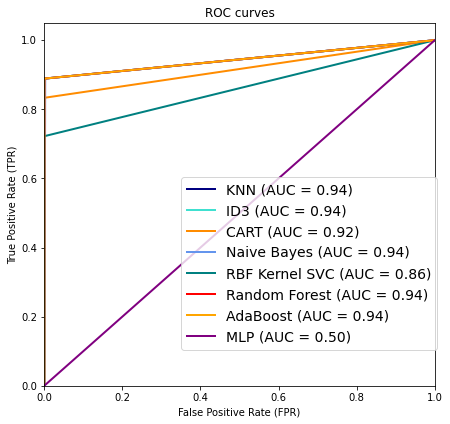

In [ ]:
from itertools import cycle

n_methods = 8
methods = ["KNN", "ID3", "CART", "Naive Bayes", "RBF Kernel SVC", "Random Forest", "AdaBoost", "MLP"]
colors = cycle(['navy', 'turquoise', 'darkorange', 'cornflowerblue', 'teal', 'red', 'orange', 'purple'])

from sklearn.metrics import roc_curve

fpr = dict()
tpr = dict()

fpr[0], tpr[0], _ = roc_curve(y_test, y_pred_knn)
fpr[1], tpr[1], _ = roc_curve(y_test, y_pred_id3)
fpr[2], tpr[2], _ = roc_curve(y_test, y_pred_cart)
fpr[3], tpr[3], _ = roc_curve(y_test, y_pred_bayes)
fpr[4], tpr[4], _ = roc_curve(y_test, y_pred_svm)
fpr[5], tpr[5], _ = roc_curve(y_test, y_pred_forest)
fpr[6], tpr[6], _ = roc_curve(y_test, y_pred_boost)
fpr[7], tpr[7], _ = roc_curve(y_test, y_pred_mlp)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import auc

plt.figure(figsize=(7, 8))
lines = []
labels = []

for i, color in zip(range(n_methods), colors):
    l, = plt.plot(fpr[i], tpr[i], color=color, lw=2)
    lines.append(l)
    labels.append('{0} (AUC = {1:0.2f})'.format(methods[i], auc(fpr[i], tpr[i])))

fig = plt.gcf()
fig.subplots_adjust(bottom=0.25)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC curves')
plt.legend(lines, labels, loc=(.35, .1), prop=dict(size=14))

plt.show()

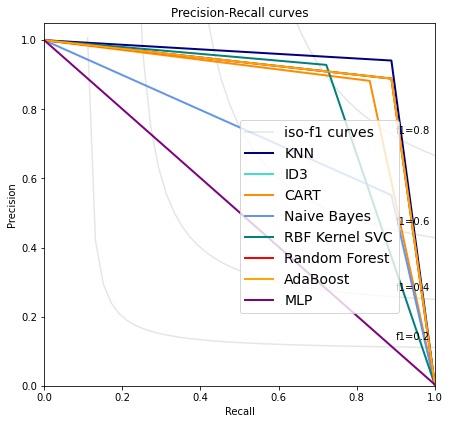

In [ ]:
from sklearn.metrics import precision_recall_curve

precision = dict()
recall = dict()

precision[0], recall[0], _ = precision_recall_curve(y_test, y_pred_knn)
precision[1], recall[1], _ = precision_recall_curve(y_test, y_pred_id3)
precision[2], recall[2], _ = precision_recall_curve(y_test, y_pred_cart)
precision[3], recall[3], _ = precision_recall_curve(y_test, y_pred_bayes)
precision[4], recall[4], _ = precision_recall_curve(y_test, y_pred_svm)
precision[5], recall[5], _ = precision_recall_curve(y_test, y_pred_forest)
precision[6], recall[6], _ = precision_recall_curve(y_test, y_pred_boost)
precision[7], recall[7], _ = precision_recall_curve(y_test, y_pred_mlp)

plt.figure(figsize=(7, 8))
lines = []
labels = []

f_scores = np.linspace(0.2, 0.8, num=4)
for f_score in f_scores:
    x = np.linspace(0.01, 1)
    y = f_score * x / (2 * x - f_score)
    l, = plt.plot(x[y >= 0], y[y >= 0], color='gray', alpha=0.2)
    plt.annotate('f1={0:0.1f}'.format(f_score), xy=(0.9, y[45] + 0.02))
lines.append(l)
labels.append('iso-f1 curves')

for i, color in zip(range(n_methods), colors):
    l, = plt.plot(recall[i], precision[i], color=color, lw=2)
    lines.append(l)
    labels.append(methods[i])

fig = plt.gcf()
fig.subplots_adjust(bottom=0.25)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curves')
plt.legend(lines, labels, loc=(.5, .2), prop=dict(size=14))

plt.show()